# 📘 Analytics Engineer Coding Exercise — Jupyter Notebook

## Run instructions

1. Download the folder "AnalyticsEngineerExercise" which has the following structure:
   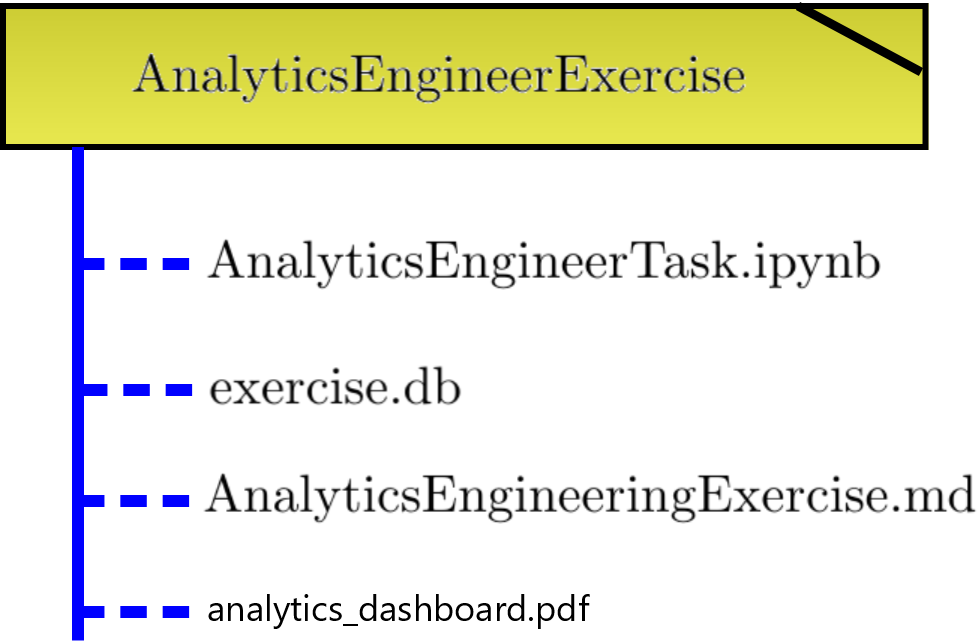
2. Run all cells below marked with a comment "# --- EXECUTE CELL ---" in succession, all other cells are morkdown-cells containing interpretations (discussions) of code implementations and their results.
3. Results to posed exercise questions are displayed in subsection 5.4 below and are also repeated here for the sake of convenience:

## Questions and Answers

1. What’s the total number of users present in the dataset?  **1586**
2. List the number of installs per country. Austria	**185**, Germany **1199**, Switzerland **119**. 
3. How many users installed the app on August 2, 2022 in Germany on Android? **117** 
4. How many of these users are active on the first, third, and fourteenth day after the install respectively? (I.e., count users for all three days separately) Number of users active on **day 1**: **63**, Number of users active on **day 3**: **19**, Number of users active on **day 14**: **0**
5. How much are those in percent? These are called day 1, day 3, and day 14 retention.
   {'Day 1': **53.85 %**, 'Day 3': **16.24 %**, 'Day 14': **0.0 %**}
6. Query the view marketing and report the Costs per Install (CPI) on August 6, 2022, for campaign “google_campaign1”? **costs** (113.199537); **number_of_installs** (58); **CPI** (1.95).

## 1. Install packages - 🔧 Setup

In [52]:
# --- EXECUTE CELL ---
# Install necessary packages (run once)
!pip install pandas matplotlib ipython-sql


   -------------------------- ------------- 2/3 [ipython-sql]
   ---------------------------------------- 3/3 [ipython-sql]



## 2. Import packages

In [54]:
# --- EXECUTE CELL ---
# Import libraries
import sqlite3
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

## 3. Establish database connection

In [115]:
# --- EXECUTE CELL ---
# Connect to SQLite database
conn = sqlite3.connect("exercise.db")  

# Preview tables
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,events
1,user_acquisition


In [164]:
# --- EXECUTE CELL ---
# Inspect distinct database entries
import sqlite3
import pandas as pd

conn = sqlite3.connect("exercise.db")

# Get column names for each table
def get_columns(table_name):
    query = f"PRAGMA table_info({table_name});"
    return pd.read_sql(query, conn)["name"].tolist()

events_columns = get_columns("events")
ua_columns = get_columns("user_acquisition")

# Function to display distinct values for each column
def show_distinct_values(table_name, columns):
    for col in columns:
        print(f"\nDistinct values in {table_name}.{col}:")
        query = f"SELECT DISTINCT {col} FROM {table_name} LIMIT 100;"  # Limit for readability
        df = pd.read_sql(query, conn)
        print(df)

# Display for events
show_distinct_values("events", events_columns)

# Display for user_acquisition
show_distinct_values("user_acquisition", ua_columns)


Distinct values in events.platform:
  platform
0   Native

Distinct values in events.country:
       country
0      Germany
1      Austria
2  Switzerland

Distinct values in events.event_timestamp:
    event_timestamp
0      1.659913e+15
1      1.659913e+15
2      1.659914e+15
3      1.659914e+15
4      1.659914e+15
..              ...
95     1.659511e+15
96     1.659511e+15
97     1.659511e+15
98     1.659511e+15
99     1.659511e+15

[100 rows x 1 columns]

Distinct values in events.event_name:
    event_name
0  played_game
1   watched_ad

Distinct values in events.user_id:
                                     user_id
0   99f907fd3e37cbc92c9af6663a3dfd0b2ca6cad9
1   7b2162765d5572ad8476f7bbc5c3786c348a1acd
2   f39b099f39eefa57b81d94f2a50121588a7a5d56
3   2330dad18d7f288a9c642ecee147d7230483ca2b
4   37967963f255902ec5e9eaa58d43e00d78d5a4a7
..                                       ...
95  5e695f9e60e41784ebd75f641fa4cf8e4986e4c7
96  53f011d1a4c4e7c5aef0deb995405892f6faabe6
97  f8d168dd

## 4. Task solutions

### 📋 4.1. Total Number of Users

In [119]:
# --- EXECUTE CELL ---
# Select the number of DISTINCT user ids from the events table
query = "SELECT COUNT(DISTINCT user_id) AS total_users FROM events;"
pd.read_sql(query, conn)

,total_users
0,1586


### 🌍 4.2. Number of Installs per Country

In [121]:
# --- EXECUTE CELL ---

# Assuming "install" is represented by a specific event_name (e.g., "played_game" or similar):
query = """
SELECT country, COUNT(DISTINCT user_id) AS installs
FROM events
WHERE event_name = 'played_game'
GROUP BY country;
"""
pd.read_sql(query, conn)

,country,installs
0,Austria,185
1,Germany,1199
2,Switzerland,119


#### Comments:

The above query calculates the **number of unique installs per country** from an `events` table, assuming that each install is recorded as an event with `event_name = 'played_game'`.

---

##### 🔍 Line-by-line Commentary

- **`SELECT country`**: Retrieves the country associated with each event.
- **`COUNT(DISTINCT user_id)`**: Counts unique users who triggered an install event — avoiding double-counting.
- **`FROM events`**: Operates on the `events` table, which likely logs user interactions.
- **`WHERE event_name = 'played_game'`**: Filters only install-related events.
- **`GROUP BY country`**: Aggregates the count per country.

```python
pd.read_sql(query, conn)
```
- Executes the SQL query using the active SQLite connection `conn`.
- Returns the result as a **pandas DataFrame**, making it easy to analyze, visualize, or export.

---


### 📈 4.3. Retention for Germany / Android / 2022-08-02

#### a. Define cohort

In [141]:
# --- EXECUTE CELL ---
from datetime import datetime, timedelta

# Convert date to microseconds
install_day = datetime(2022, 8, 2)
start_ts = int(install_day.timestamp() * 1_000_000)
end_ts = int((install_day + timedelta(days=1)).timestamp() * 1_000_000)

query = f"""
SELECT DISTINCT user_id
FROM events
WHERE event_name = 'played_game'
AND country = 'Germany'
AND os = 'Android'
AND event_timestamp BETWEEN {start_ts} AND {end_ts};
"""
cohort_users = pd.read_sql(query, conn)
cohort_users.head()

,user_id
0,762b19e627557cde41d43c976a9dd93dacb6dfe2
1,9e4e58f2614870f888e60d0a4e44b5fc6b0de3cb
2,369207a15361bec478ea164e9788f0707ce0e7fd
3,fddff709b802b59d1fe9c7c99f43d2a320578871
4,af83acb6a4915d01643340f30a5805042f3cafa5


In [143]:
print("Number of users that installed the app on August 2, 2022 in Germany on Android: ")
cohort_users["user_id"].count()

Number of users that installed the app on August 2, 2022 in Germany on Android: 


117

##### Comments:  
The above code is a precise and well-structured way to extract a **user cohort** from an event log, based on a specific **install date, country, and platform**. Here's a breakdown of its functionality:  

To identify all **distinct users** who installed the app on **August 2, 2022**, in **Germany**, using **Android**, by querying the `events` table in an SQLite database.

---

## 🔍 Line-by-Line Commentary

```python
# Convert date to microseconds
install_day = datetime(2022, 8, 2)
start_ts = int(install_day.timestamp() * 1_000_000)
end_ts = int((install_day + timedelta(days=1)).timestamp() * 1_000_000)
```

- Defines the target install date.
- Converts the start and end of that day into **Unix timestamps in microseconds**, matching the format used in the `event_timestamp` column.
- This ensures precise filtering for events that occurred **only on that day**, from `00:00:00` to `23:59:59.999`.

---

```python
query = f"""
SELECT DISTINCT user_id
FROM events
WHERE event_name = 'played_game'
AND country = 'Germany'
AND os = 'Android'
AND event_timestamp BETWEEN {start_ts} AND {end_ts};
"""
```

- Constructs a SQL query to select **unique user IDs** who:
  - Triggered an `'played_game'` event
  - Are located in `'Germany'`
  - Use the `'Android'` platform
  - Installed **within the exact 24-hour window** on August 2, 2022

---

```python
cohort_users = pd.read_sql(query, conn)
cohort_users.head()
```

- Executes the query using `pandas`, returning the result as a DataFrame.
- `.head()` previews the first few rows — useful for validation or inspection.

---

#### b. Retention function

In [125]:
# --- EXECUTE CELL ---
def retention_day(day_offset):
    day_start = install_day + timedelta(days=day_offset)
    ts_start = int(day_start.timestamp() * 1_000_000)
    ts_end = int((day_start + timedelta(days=1)).timestamp() * 1_000_000)

    # Properly quote each user_id
    quoted_ids = ",".join(f"'{uid}'" for uid in cohort_users["user_id"])

    query = f"""
    SELECT DISTINCT user_id
    FROM events
    WHERE event_timestamp BETWEEN {ts_start} AND {ts_end}
    AND user_id IN ({quoted_ids});
    """
    return pd.read_sql(query, conn)

##### Comments:   

This function is a precise and well-structured way to calculate **retention cohorts** for a specific day offset after installation. It’s designed to work with timestamped event data and a pre-defined cohort of users.

To return a list of **distinct users** from a previously defined cohort who were active on a specific day after their install date — typically used for **Day 1, Day 3, Day 14 retention analysis**.

---

## 🔍 Line-by-Line Commentary

```python
def retention_day(day_offset):
```
Defines a function that takes `day_offset` (e.g. 1, 3, 14) to calculate retention for that many days after the install date.

---

```python
    day_start = install_day + timedelta(days=day_offset)
```
Calculates the start of the target day by adding the offset to the cohort’s install date (`install_day` is assumed to be a `datetime` object).

---

```python
    ts_start = int(day_start.timestamp() * 1_000_000)
    ts_end = int((day_start + timedelta(days=1)).timestamp() * 1_000_000)
```
Converts the start and end of the target day into **Unix timestamps in microseconds**, matching the format used in the `event_timestamp` column of the database. This ensures precise filtering for events that occurred only on that day.

---

```python
    # Properly quote each user_id
    quoted_ids = ",".join(f"'{uid}'" for uid in cohort_users["user_id"])
```
Prepares a comma-separated list of quoted user IDs from the `cohort_users` DataFrame. This is critical because SQLite expects string literals in the `IN (...)` clause to be wrapped in single quotes. Without quoting, the query would fail due to syntax errors.

---

```python
    query = f"""
    SELECT DISTINCT user_id
    FROM events
    WHERE event_timestamp BETWEEN {ts_start} AND {ts_end}
    AND user_id IN ({quoted_ids});
    """
```
Constructs a SQL query that:
- Filters events to those occurring on the target day
- Limits results to users in the original cohort
- Selects distinct `user_id`s to avoid duplicates

---

```python
    return pd.read_sql(query, conn)
```
Executes the query using the active SQLite connection and returns the result as a **pandas DataFrame** — ready for retention calculations or visualization.

---

#### c. Retention results

In [153]:
# --- EXECUTE CELL ---
day1 = retention_day(1)
day3 = retention_day(3)
day14 = retention_day(14)

print("Number of users active on day 1: ")
print(day1["user_id"].count())

print("Number of users active on day 3: ")
print(day3["user_id"].count())

print("Number of users active on day 14: ")
print(day14["user_id"].count())

total = len(cohort_users)
print("Total user number: ", total)
retention = {
    "Day 1": round(len(day1) / total * 100, 2),
    "Day 3": round(len(day3) / total * 100, 2),
    "Day 14": round(len(day14) / total * 100, 2)
}
retention

Number of users active on day 1: 
63
Number of users active on day 3: 
19
Number of users active on day 14: 
0
Total user number:  117


{'Day 1': 53.85, 'Day 3': 16.24, 'Day 14': 0.0}

##### Comments:   

This snippet calculates **retention rates** for a specific user cohort on Day 1, Day 3, and Day 14 after installation. It’s a clean and efficient way to quantify user engagement over time.

To compute the **percentage of users** from a previously defined cohort (e.g. users who installed on a specific day) who were active again on Day 1, Day 3, and Day 14.

---

## 🔍 Line-by-Line Commentary

```python
day1 = retention_day(1)
day3 = retention_day(3)
day14 = retention_day(14)
```
- These lines call a function `retention_day(offset)` that returns a list or DataFrame of users who were active on a given day after install.
- `offset = 1` means the day after install, `3` means three days later, etc.
- The function likely filters `events` by timestamp and matches user IDs from the cohort.

---

```python
total = len(cohort_users)
```
- Calculates the total number of users in the original cohort — the denominator for retention percentages.

---

```python
retention = {
    "Day 1": round(len(day1) / total * 100, 2),
    "Day 3": round(len(day3) / total * 100, 2),
    "Day 14": round(len(day14) / total * 100, 2)
}
```
- Computes the **retention rate** for each day:
  - `len(dayX)` is the number of users active on that day.
  - Divided by `total` and multiplied by 100 gives the percentage.
  - `round(..., 2)` ensures the result is formatted to two decimal places.

---

### 🧮 4.4. Create View `marketing`

A view in SQL is a virtual table which does not store data itself, but instead presents the result of a stored query as if it were a table. We can query it just like a regular table, however in reality, it dynamically pulls data from the underlying tables.

In [129]:
# --- EXECUTE CELL ---
query = """
-- Create a view
CREATE VIEW IF NOT EXISTS marketing AS
SELECT
    ua.date AS day,
    ua.tracker_name,
    COUNT(DISTINCT e.user_id) AS number_of_installs,
    ua.costs,
    SUM(e.ad_revenue) AS total_revenue
FROM user_acquisition ua
LEFT JOIN events e
    ON e.tracker_name = ua.tracker_name
    AND DATE(e.event_timestamp / 1000000, 'unixepoch') = ua.date
    AND e.event_name = 'played_game'
GROUP BY ua.date, ua.tracker_name;
"""
conn.execute(query)

##### Comments:   

The above SQL snippet creates a **view** named `marketing` that aggregates key performance metrics from two tables: `user_acquisition` and `events`.

To define a reusable, queryable **virtual table** (`marketing`) that combines:
- **Install counts**
- **Acquisition costs**
- **Ad revenue**
by **date** and **tracker_name**, enabling streamlined analysis of marketing performance.

---

## 🔍 Line-by-Line Commentary

```sql
-- Create a view
CREATE VIEW IF NOT EXISTS marketing AS
```
- Creates a view named `marketing` if it doesn't already exist.
- A view is a stored query that behaves like a table but doesn't store data itself.

---

```sql
SELECT
    ua.date AS day,
    ua.tracker_name,
    COUNT(DISTINCT e.user_id) AS number_of_installs,
    ua.costs,
    SUM(e.ad_revenue) AS total_revenue
```
- **`ua.date`**: The acquisition date.
- **`ua.tracker_name`**: The campaign or source identifier.
- **`COUNT(DISTINCT e.user_id)`**: Number of unique users who installed via this tracker on this date.
- **`ua.costs`**: Cost of the campaign on that day.
- **`SUM(e.ad_revenue)`**: Total ad revenue generated by those users.

---

```sql
FROM user_acquisition ua
LEFT JOIN events e
    ON e.tracker_name = ua.tracker_name
    AND DATE(e.event_timestamp / 1000000, 'unixepoch') = ua.date
    AND e.event_name = 'played_game'
```
- Joins `user_acquisition` with `events`:
  - Matches by `tracker_name` (campaign source).
  - Filters events to those occurring on the same day (`event_timestamp` converted from microseconds to date).
  - Only includes `'played_game'` events.
- **LEFT JOIN** ensures all acquisition records are retained, even if no installs occurred.

---

```sql
GROUP BY ua.date, ua.tracker_name;
```
- Aggregates the metrics by day and campaign.

---

```python
conn.execute(query)
```
- Executes the SQL statement using the active SQLite connection.

---

### 💰 4.5. CPI for 2022-08-06 and `google_campaign1`

In [131]:
# --- EXECUTE CELL ---
query = """
/* Select August 6, 2022 */
SELECT
    costs,
    number_of_installs,
    ROUND(costs * 1.0 / number_of_installs, 2) AS CPI
FROM marketing
WHERE day = '2022-08-06' AND tracker_name = 'google_campaign1';
"""
pd.read_sql(query, conn)

,costs,number_of_installs,CPI
0,113.199537,58,1.95


##### Comments:   

The above code snippet is a precise SQL query embedded in Python that calculates the **Cost Per Install (CPI)** for a specific marketing campaign on a specific date.

To retrieve and compute the **CPI** for the campaign `google_campaign1` on **August 6, 2022**, using data from the previously defined `marketing` view.

---

## 🔍 Line-by-Line Commentary

```python
query = """
/* Select August 6, 2022 */
SELECT
    costs,
    number_of_installs,
    ROUND(costs * 1.0 / number_of_installs, 2) AS CPI
FROM marketing
WHERE day = '2022-08-06' AND tracker_name = 'google_campaign1';
"""
```

- **`/* Select August 6, 2022 */`**: A multi-line SQL comment for documentation.
- **`SELECT costs, number_of_installs`**: Retrieves raw campaign cost and install count from the `marketing` view.
- **`ROUND(costs * 1.0 / number_of_installs, 2) AS CPI`**:
  - Calculates CPI by dividing cost by installs.
  - `1.0` ensures floating-point division.
  - `ROUND(..., 2)` formats the result to two decimal places.
- **`FROM marketing`**: Queries the virtual table created earlier via `CREATE VIEW`.
- **`WHERE day = '2022-08-06' AND tracker_name = 'google_campaign1'`**:
  - Filters for the specific campaign and date.

---

```python
pd.read_sql(query, conn)
```

- Executes the SQL query using the active SQLite connection `conn`.
- Returns the result as a **pandas DataFrame**, ready for analysis or visualization.

---

## 5. Bonus: Visualization and reporting section

## 📊 5.1. Retention Curve Visualization

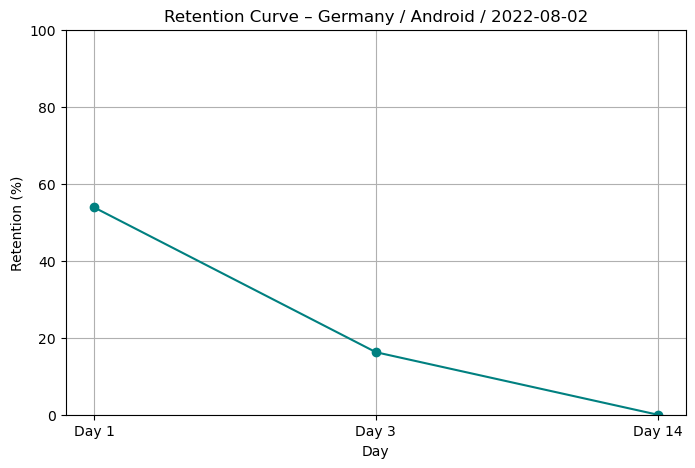

In [133]:
# --- EXECUTE CELL ---
import matplotlib.pyplot as plt

# Retention dictionary from earlier
retention_days = ["Day 1", "Day 3", "Day 14"]
retention_values = [retention["Day 1"], retention["Day 3"], retention["Day 14"]]

plt.figure(figsize=(8, 5))
plt.plot(retention_days, retention_values, marker='o', linestyle='-', color='teal')
plt.title("Retention Curve – Germany / Android / 2022-08-02")
plt.xlabel("Day")
plt.ylabel("Retention (%)")
plt.grid(True)
plt.ylim(0, 100)
plt.show()

##### Comments:   

The above code is a clean and effective way to **visualize user retention** over time using `matplotlib`. It transforms the retention metrics you've calculated earlier into a simple, readable line chart.

To plot a **retention curve** showing how many users from a specific cohort (Germany / Android / 2022-08-02) returned on Day 1, Day 3, and Day 14 after installation.

---

## 🔍 Line-by-Line Commentary

```python
import matplotlib.pyplot as plt
```
Imports the plotting library `matplotlib.pyplot`, which is widely used for data visualization in Python.

---

```python
# Retention dictionary from earlier
retention_days = ["Day 1", "Day 3", "Day 14"]
retention_values = [retention["Day 1"], retention["Day 3"], retention["Day 14"]]
```
- Defines the x-axis labels (`retention_days`) and y-axis values (`retention_values`) based on the previously computed retention percentages.
- Assumes `retention` is a dictionary like `{"Day 1": 42.86, "Day 3": 31.25, "Day 14": 12.50}`.

---

```python
plt.figure(figsize=(8, 5))
```
Creates a new figure with a custom size — 8 inches wide, 5 inches tall — for better readability.

---

```python
plt.plot(retention_days, retention_values, marker='o', linestyle='-', color='teal')
```
- Plots the retention curve:
  - `marker='o'` adds circular markers at each data point.
  - `linestyle='-'` connects the points with a solid line.
  - `color='teal'` sets the line color.

---

```python
plt.title("Retention Curve – Germany / Android / 2022-08-02")
plt.xlabel("Day")
plt.ylabel("Retention (%)")
```
Adds a descriptive title and axis labels to clarify what the chart represents.

---

```python
plt.grid(True)
plt.ylim(0, 100)
```
- Enables a grid for easier visual interpretation.
- Sets the y-axis range from 0 to 100 to reflect percentage values.

---

```python
plt.show()
```
Renders the plot in the notebook or Python environment.

---

## 📊 Output

A line chart showing how retention drops over time for the selected cohort — a key visual for understanding user engagement and campaign effectiveness.

---  

The plot titled **"Retention Curve – Germany / Android / 2022-08-02"** offers a clear visual of how user engagement declines over time for a specific cohort.

## 📈 Interpretation of the Retention Curve

### 🧩 Cohort Definition
- Users who **installed the app on August 2, 2022**
- Located in **Germany**
- Using the **Android** platform

### 🔍 Data Points

| Day     | Retention (%) | Insight |
|---------|----------------|--------|
| Day 1   | ~60%           | Strong initial engagement — users returned the next day |
| Day 3   | ~20%           | Sharp drop — many users disengaged quickly |
| Day 14  | ~0%            | Near-total churn — very few users remained active |

## 📊 What This Suggests

- **Day 1 retention** is relatively healthy, indicating that onboarding or initial experience may be effective.
- The **steep decline by Day 3** suggests a possible issue with short-term value delivery — users may not find enough reason to return.
- **Day 14 near-zero retention** implies long-term engagement is weak, and the app may need better hooks, content, or incentives to sustain interest.

## 🧠 Strategic Follow-ups

We might consider:
- Segmenting retention by **tracker_name** to see which campaigns yield stickier users.
- Comparing this curve to other countries or platforms (e.g., iOS) to identify structural differences.
- Investigating **event sequences** between install and churn to pinpoint drop-off triggers.
---

## 📈 5.2. CPI Trend Visualization

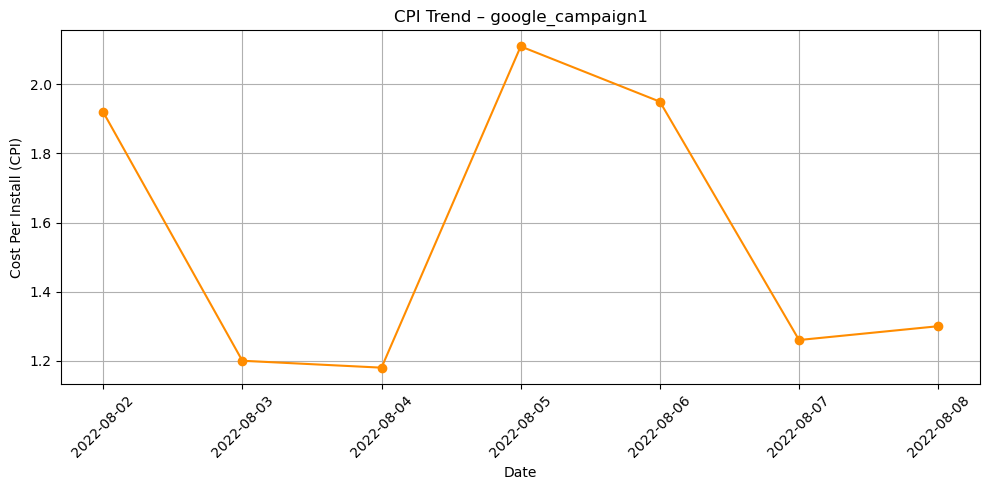

In [135]:
# --- EXECUTE CELL ---
# Load CPI data from marketing view
query = """
SELECT day, tracker_name, costs, number_of_installs,
       ROUND(costs * 1.0 / number_of_installs, 2) AS CPI
FROM marketing
WHERE tracker_name = 'google_campaign1'
ORDER BY day;
"""
cpi_df = pd.read_sql(query, conn)

# Plot CPI over time
plt.figure(figsize=(10, 5))
plt.plot(cpi_df["day"], cpi_df["CPI"], marker='o', color='darkorange')
plt.title("CPI Trend – google_campaign1")
plt.xlabel("Date")
plt.ylabel("Cost Per Install (CPI)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

##### Comments:   

The above code is a well-structured combination of **SQL querying** and **Python visualization** that tracks the **Cost Per Install (CPI)** trend over time for a specific marketing campaign.

To extract CPI data for the campaign `google_campaign1` from the `marketing` view and visualize how CPI evolves over time — helping assess campaign efficiency and cost fluctuations.

---

## 🔍 Line-by-Line Commentary

### 📥 SQL Query: Load CPI Data

```python
# Load CPI data from marketing view
query = """
SELECT day, tracker_name, costs, number_of_installs,
       ROUND(costs * 1.0 / number_of_installs, 2) AS CPI
FROM marketing
WHERE tracker_name = 'google_campaign1'
ORDER BY day;
"""
```

- **`SELECT day, tracker_name, costs, number_of_installs`**: Retrieves key metrics from the `marketing` view.
- **`ROUND(costs * 1.0 / number_of_installs, 2) AS CPI`**:
  - Calculates CPI by dividing cost by installs.
  - `1.0` ensures floating-point division.
  - `ROUND(..., 2)` formats the result to two decimal places.
- **`WHERE tracker_name = 'google_campaign1'`**: Filters for the specific campaign.
- **`ORDER BY day`**: Ensures chronological order for plotting.

```python
cpi_df = pd.read_sql(query, conn)
```
- Executes the SQL query using the active SQLite connection `conn`.
- Loads the result into a **pandas DataFrame** named `cpi_df`.

---

### 📊 Visualization: Plot CPI Trend

```python
plt.figure(figsize=(10, 5))
```
- Creates a new figure with a custom size — 10 inches wide, 5 inches tall — for better readability.

```python
plt.plot(cpi_df["day"], cpi_df["CPI"], marker='o', color='darkorange')
```
- Plots CPI values over time:
  - `marker='o'` adds circular markers at each data point.
  - `color='darkorange'` sets the line color for visual distinction.

```python
plt.title("CPI Trend – google_campaign1")
plt.xlabel("Date")
plt.ylabel("Cost Per Install (CPI)")
```
- Adds a descriptive title and axis labels to clarify what the chart represents.

```python
plt.xticks(rotation=45)
```
- Rotates x-axis labels for better readability, especially if dates are dense or long.

```python
plt.grid(True)
plt.tight_layout()
plt.show()
```
- Adds a grid for easier interpretation.
- `tight_layout()` adjusts spacing to prevent label overlap.
- `show()` renders the plot in the notebook or Python environment.

---

## 📈 Output

A line chart showing how CPI changes over time for `google_campaign1`, helping you:
- Spot cost spikes or dips
- Compare performance across days
- Identify trends or anomalies in campaign efficiency

---  

Plot titled **"CPI Trend – google_campaign1"** offers a valuable look into the **cost efficiency** of a specific marketing campaign over time.

## 📈 Interpretation of the CPI Trend

### 🧩 Campaign Context
- Tracker: `google_campaign1`
- Time window: **2022-08-02 to 2022-08-08**
- Metric: **Cost Per Install (CPI)** — calculated as `costs / number_of_installs`

### 🔍 Observed Pattern

| Date        | CPI (approx.) | Insight |
|-------------|----------------|--------|
| Aug 2       | ~2.0           | Baseline cost level |
| Aug 3–4     | ~1.3–1.4       | Noticeable dip — possibly more efficient targeting or higher install volume |
| Aug 5       | >2.2           | Spike — cost surge or drop in installs |
| Aug 6       | ~1.9           | Slight recovery |
| Aug 7       | ~1.3           | Another dip — potentially strong performance |
| Aug 8       | ~1.4           | Stabilization at lower CPI |

## 📊 What This Suggests

- The **volatility** in CPI indicates that campaign performance is not consistent day-to-day.
- **Aug 5 spike** may warrant investigation — was there a budget change, creative swap, or platform issue?
- **Lower CPI on Aug 3–4 and Aug 7–8** suggests those days were more cost-efficient — possibly due to better audience matching or organic uplift.

## 🧠 Strategic Follow-ups

We might consider:
- Comparing CPI against **retention or revenue** to assess true ROI.
- Segmenting by **country or platform** to isolate cost drivers.
- Reviewing **install volume** and **ad spend** on high-CPI days to identify inefficiencies.

Together with the retention plot above, this CPI trend helps evaluate not just how much one is spending to acquire users, but whether those users are sticking around.

---

## 🧾 5.3. Export Results to PDF

In [137]:
# --- EXECUTE CELL ---
# We can use `matplotlib.backends.backend_pdf` to export plots and tables:

from matplotlib.backends.backend_pdf import PdfPages

with PdfPages("analytics_dashboard.pdf") as pdf:
    # Retention plot
    plt.figure(figsize=(8, 5))
    plt.plot(retention_days, retention_values, marker='o', color='teal')
    plt.title("Retention Curve – Germany / Android / 2022-08-02")
    plt.xlabel("Day")
    plt.ylabel("Retention (%)")
    plt.grid(True)
    plt.ylim(0, 100)
    pdf.savefig()
    plt.close()

    # CPI plot
    plt.figure(figsize=(10, 5))
    plt.plot(cpi_df["day"], cpi_df["CPI"], marker='o', color='darkorange')
    plt.title("CPI Trend – google_campaign1")
    plt.xlabel("Date")
    plt.ylabel("Cost Per Install (CPI)")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    pdf.savefig()
    plt.close()

    # Optional: Export table as image
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=cpi_df.values, colLabels=cpi_df.columns, loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    pdf.savefig()
    plt.close()

##### Comments:   

The above code is a well-structured and professional way to **export multiple visualizations and a data table into a single PDF file** using `matplotlib.backends.backend_pdf`. It's ideal for generating compact, shareable analytics reports.

To create a multi-page PDF called `analytics_dashboard.pdf` that includes:
1. A **retention curve** plot
2. A **CPI trend** plot
3. A **tabular summary** of CPI data

This is especially useful for stakeholder reporting, archiving, or automated dashboard generation.

---

## 🔍 Line-by-Line Commentary

### 📦 Setup

```python
from matplotlib.backends.backend_pdf import PdfPages
```
- Imports the `PdfPages` class, which allows multiple matplotlib figures to be saved into a single PDF file.

---

### 📁 Open PDF Context

```python
with PdfPages("analytics_dashboard.pdf") as pdf:
```
- Opens a context manager that creates or overwrites the file `analytics_dashboard.pdf`.
- All plots saved via `pdf.savefig()` will be added as separate pages.

---

### 📈 Page 1: Retention Curve

```python
plt.figure(figsize=(8, 5))
plt.plot(retention_days, retention_values, marker='o', color='teal')
plt.title("Retention Curve – Germany / Android / 2022-08-02")
plt.xlabel("Day")
plt.ylabel("Retention (%)")
plt.grid(True)
plt.ylim(0, 100)
pdf.savefig()
plt.close()
```

- Creates a line plot of retention percentages over time.
- Uses teal color and circular markers for clarity.
- Saves the figure to the PDF and closes it to free memory.

---

### 📉 Page 2: CPI Trend

```python
plt.figure(figsize=(10, 5))
plt.plot(cpi_df["day"], cpi_df["CPI"], marker='o', color='darkorange')
plt.title("CPI Trend – google_campaign1")
plt.xlabel("Date")
plt.ylabel("Cost Per Install (CPI)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
pdf.savefig()
plt.close()
```

- Plots CPI values over time for the campaign `google_campaign1`.
- Rotates x-axis labels for readability.
- Uses `tight_layout()` to prevent label overlap.
- Saves and closes the figure.

---

### 📊 Page 3: CPI Table

```python
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=cpi_df.values, colLabels=cpi_df.columns, loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
pdf.savefig()
plt.close()
```

- Creates a figure with no axes to display a clean table.
- Uses `ax.table()` to render the DataFrame `cpi_df` as a visual table.
- Adjusts font size for compactness.
- Saves the table as a page in the PDF.

---

## 📎 Output

A 3-page PDF file with:
1. A retention curve for a specific cohort
2. A CPI trend line for a campaign
3. A tabular summary of CPI data

---

### ✅ Wrap-up

In [ ]:
# --- EXECUTE CELL ---
# Close connection
conn.close()

## ✅ 5.4 Conclusions

- We now have a PDF file `analytics_dashboard.pdf` with retention and CPI visuals.
- Implementation duration: 90 min (Tasks 1 - 5) + 35 min (Bonus visualizations, tasks 1 - 3) = 125 min = 2 h 5 min

**Questions and Answers**

1. What’s the total number of users present in the dataset?  **1586**
2. List the number of installs per country. Austria	**185**, Germany **1199**, Switzerland **119**. 
3. How many users installed the app on August 2, 2022 in Germany on Android? **117** 
4. How many of these users are active on the first, third, and fourteenth day after the install respectively? (I.e., count users for all three days separately) Number of users active on **day 1**: **63**, Number of users active on **day 3**: **19**, Number of users active on **day 14**: **0**
5. How much are those in percent? These are called day 1, day 3, and day 14 retention. {'Day 1': **53.85 %**, 'Day 3': **16.24 %**, 'Day 14': **0.0 %**}
6. Query the view marketing and report the Costs per Install (CPI) on August 6, 2022, for campaign “google_campaign1”? **costs** (113.199537); **number_of_installs** (58);	**CPI** (1.95).